# Classifier Free Guidance Tests - UWM pushT - Sampling Experiments

Diagnostic notebook for the **pushT `horizon_aware=False`** (purely-causal) UWM
checkpoint. Everything operates on tokenizer latents. After a shared setup it
runs two families of sampling experiments:

- **Part I — Classifier-free guidance.** A `getVelField` primitive returning the
  flow-matching velocity at a given cleanness, used to build unconditional video
  generation, goal-anchored generation, and a classifier-free-guidance weight
  sweep that blends unconditional and context-conditioned velocities.

- **Part II — Horizon sampling: batch-mode vs autoregressive.** Condition on a
  few clean context frames and generate the future horizon two ways — denoising
  the whole horizon in parallel (batch mode) vs a KV-cached frame-by-frame
  rollout (`HybridChunkSampler`) — scored against the ground-truth continuation.

**Convention.** The denoiser is an *x-predictor* at cleanness `tau`
(`tau=0` → pure noise, `tau=1` → clean). The flow-matching velocity is
`v = (x_hat - x) / (1 - tau)`, integrated with forward Euler over `K` steps.
Noise levels are passed to the model as quantized indices in
`[0, num_noise_levels - 1]`.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import math
import torch
import numpy as np
import mediapy
import matplotlib.pyplot as plt
from torch.nn.functional import interpolate

from hydra import initialize, compose
from omegaconf import OmegaConf

from dreamerv4uwm.models.utils import load_tokenizer, load_denoiser
from dreamerv4uwm.datasets import G1ChunkDataset, ShardedHDF5Dataset
from dreamerv4uwm.sampling_new import make_is_horizon, _quantize_tau_to_idx
from dreamerv4uwm.inference.hybrid_chunk import HybridChunkSampler

torch.manual_seed(0)  # reproducible noise priors
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
resolution = (256, 256)

## 2. Config & checkpoints

`pushT-large` matches this checkpoint's architecture (`model_dim=1024`,
`n_layers=8`). We override `horizon_aware=false` because the checkpoint was
trained without the `frame_id_embedder` / horizon-aware temporal mask.

In [2]:
with initialize(version_base=None, config_path='../scripts/config'):
    cfg = compose(
        config_name='dynamics/pushT-large',
        overrides=['denoiser.horizon_aware=false'],
    )

cfg.dynamics_ckpt = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/blockcausal/pushT-post-train/97500.pt'
cfg.tokenizer_ckpt = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/pushT.pt'

print('horizon_aware:', cfg.denoiser.get('horizon_aware', False))
print('model_dim / n_layers:', cfg.denoiser.model_dim, '/', cfg.denoiser.n_layers)

horizon_aware: False
model_dim / n_layers: 1024 / 8


/home/mim-server/miniconda3/envs/dreamerv4uwm/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT-large': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


## 3. Load denoiser + tokenizer

In [3]:
denoiser = load_denoiser(cfg, device, max_num_forward_steps=300).eval().cuda()
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300).eval().cuda()

# None for this checkpoint; a DiscreteEmbedder(2, model_dim) when horizon_aware=true.
print('frame_id_embedder:', denoiser.model.frame_id_embedder)

frame_id_embedder: None


## 4. Held-out window → latents

Load one fixed 64-frame window from the held-out loader and encode its frames
to tokenizer latents `(1, T, N_lat=256, D_lat=32)`.

In [4]:
DATA_PATH = '/home/mim-server/datasets/pushT/h5/play'
dataset = ShardedHDF5Dataset(
    data_dir=DATA_PATH, window_size=64, stride=1,
    split='train', train_fraction=0.9, split_seed=123,
)

batch = dataset[1234]  # fixed index for reproducibility
imgs = interpolate(batch['image'], resolution).to(device)[None]          # (1, T, 3, 256, 256)
actions = batch['action'][:, :cfg.denoiser.n_actions][None].to(device)   # (1, T, n_act)

with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    latents = tokenizer.encode(imgs)                                     # (1, T, N_lat, D_lat)
latents = latents.float()  # samplers integrate in fp32 for numerical headroom
print('imgs:', tuple(imgs.shape), '| actions:', tuple(actions.shape), '| latents:', tuple(latents.shape))

Train split: 64694 windows from 11 episodes
imgs: (1, 64, 3, 256, 256) | actions: (1, 64, 2) | latents: (1, 64, 256, 32)


## 5. Display & scoring helpers

`plotVideo` plays a clip; `plotSnapshots` / `plotComparison` render filmstrips;
`decode` maps latents back to images; `latent_mse` scores against ground truth.

In [5]:
def plotVideo(video, fps=10):
    """Play a (T, C, H, W) float[0,1] clip inline."""
    arr = (video.cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255).clip(0, 255).astype(np.uint8)
    mediapy.show_video(arr, fps=fps)


def _strip(video_tchw, n_frames=8, border=2):
    """(T, C, H, W) float[0,1] -> horizontal uint8 filmstrip of `n_frames` samples."""
    T = video_tchw.shape[0]
    idx = np.linspace(0, T - 1, min(n_frames, T), dtype=int)
    fr = (video_tchw[idx].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255).clip(0, 255).astype(np.uint8)
    H, W, C = fr.shape[1:]
    sep = np.full((H, border, C), 255, np.uint8)
    parts = []
    for i, f in enumerate(fr):
        if i:
            parts.append(sep)
        parts.append(f)
    return np.concatenate(parts, axis=1)


def plotSnapshots(video, n_frames=8, figsize=None):
    """Show a single clip as one filmstrip row."""
    strip = _strip(video, n_frames)
    figsize = figsize or (n_frames * 2, 2.2)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip); ax.axis('off'); plt.tight_layout(); plt.show()


def plotComparison(named_videos, n_frames=8, title=None):
    """Stack labeled clips as filmstrip rows for side-by-side comparison.

    Args:
        named_videos: list of (label, video) with video shaped (T, C, H, W) in [0, 1].
        n_frames: frames sampled per row.
        title: optional figure title above the top row.
    """
    rows = [(lab, _strip(v, n_frames)) for lab, v in named_videos]
    fig, axes = plt.subplots(len(rows), 1, figsize=(n_frames * 2, 2.0 * len(rows)))
    if len(rows) == 1:
        axes = [axes]
    for ax, (lab, img) in zip(axes, rows):
        ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
        ax.set_ylabel(lab, rotation=0, ha='right', va='center', fontsize=10)
    if title:
        axes[0].set_title(title, fontsize=12)
    plt.tight_layout(); plt.show()


def plotActions(actions, dim_labels=None, ylim=(-1.0, 1.0)):
    """Line-plot each action dimension over time."""
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    for d in range(act.shape[-1]):
        ax.plot(act[:, d], linewidth=1.2, alpha=0.85,
                label=dim_labels[d] if dim_labels else f'dim {d}')
    ax.set_ylim(*ylim); ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout(); plt.show()


@torch.no_grad()
def decode(lat):
    """Decode latents (B, T, N_lat, D_lat) -> video (B, T, 3, H, W) float[0,1]."""
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        v = tokenizer.decode(lat.to(device))
    return v.float().clamp(0, 1)


def latent_mse(x, y):
    """Mean-squared error between two latent tensors (broadcast-compatible)."""
    return torch.mean((x.float() - y.float()) ** 2).item()

## 6. Context / horizon split

The first `T_ctx` frames are the clean conditioning context; the next `T_hor`
frames are the ground-truth continuation used for scoring in Part II.

In [6]:
T_ctx = 8       # conditioning frames
T_hor = 32      # ground-truth horizon length used for scoring

ctx_latents = latents[:, :T_ctx].clone()
ctx_actions = actions[:, :T_ctx].clone()
gt_horizon  = latents[:, T_ctx:T_ctx + T_hor].clone()
print('ctx:', tuple(ctx_latents.shape), '| gt_horizon:', tuple(gt_horizon.shape))

ctx: (1, 8, 256, 32) | gt_horizon: (1, 32, 256, 32)


# Part I — Classifier-free guidance

We build the velocity-field primitive used for **classifier-free guidance (CFG)**:
run the denoiser twice per step — once unconditional, once conditioned on a clean
anchor frame — and blend the two velocities

```
v = v_uncond + w * (v_cond - v_uncond)
```

where `w` is the guidance strength (`w=0` → unconditional, larger `w` → push
harder toward the conditioned distribution).

## 7. Velocity-field building block — `getVelField`

One denoiser query at cleanness `tau` returning the x-prediction and the
flow-matching velocity `v = (x_hat - x) / (1 - tau)` for the horizon frames.
An optional clean `context` block (held at `context_tau`) can be concatenated
before or after the horizon so the horizon attends to it. This single primitive
backs unconditional, context-conditioned, and CFG sampling.

In [7]:
@torch.no_grad()
def getVelField(denoiser, z, tau, context=None, context_tau=0.9, context_at_end=False):
    """Query the denoiser once at cleanness ``tau``; return (x_pred, velocity)
    for the horizon frames ``z``.

    Args:
        denoiser: DenoiserWrapper.
        z: horizon latents being integrated (1, T_hor, N_lat, D_lat).
        tau: current cleanness in [0, 1) (0 = pure noise).
        context: optional clean latents (1, T_ctx, N_lat, D_lat) to condition on.
        context_tau: cleanness pinned on the context frames (~1 = clean).
        context_at_end: append context after the horizon instead of before
            (use a *future* anchor, i.e. goal-conditioning).

    Returns:
        (x, v): x-prediction and velocity, both sliced back to the horizon
        frames only — shapes (1, T_hor, N_lat, D_lat).
    """
    d = denoiser.cfg.denoiser
    N, n_act = d.num_noise_levels, d.n_actions
    device = z.device
    # Assemble the attended sequence (horizon +/- context).
    if context is None:
        z_t = z
    elif context_at_end:
        z_t = torch.cat([z, context], dim=1)
    else:
        z_t = torch.cat([context, z], dim=1)
    T = z_t.shape[1]
    is_hor = make_is_horizon(T, all_bidir=True, device=device)         # ignored when horizon_aware=false
    a = torch.randn(1, T, n_act, device=device)
    step_idx = torch.zeros((1, T), dtype=torch.long, device=device)
    obs_sigma = torch.full((1, T), _quantize_tau_to_idx(tau, N), dtype=torch.long, device=device)
    act_sigma = torch.full((1, T), _quantize_tau_to_idx(0.0, N), dtype=torch.long, device=device)
    if context is not None:                                            # pin context frames clean
        Tc = context.shape[1]
        ctx_idx = _quantize_tau_to_idx(context_tau, N)
        if context_at_end:
            obs_sigma[:, -Tc:] = ctx_idx
        else:
            obs_sigma[:, :Tc] = ctx_idx
    z_hat, _, _ = denoiser(
        noisy_act=a, noisy_obs=z_t,
        obs_sigma_idx=obs_sigma, obs_step_idx=step_idx,
        act_sigma_idx=act_sigma, act_step_idx=step_idx, is_horizon=is_hor,
    )
    v = (z_hat - z_t) / (1.0 - tau)
    x = z_hat
    if context is None:
        return x, v
    return (x[:, :-Tc], v[:, :-Tc]) if context_at_end else (x[:, Tc:], v[:, Tc:])

## 8. Unconditional video generation — `videoSampler`

Integrate a horizon from pure noise to clean with full bidirectional attention
and no conditioning. Returns the final x-prediction latents.

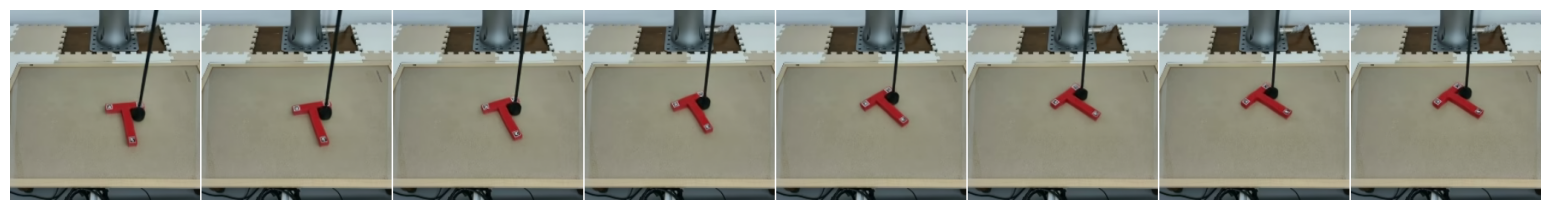

In [8]:
@torch.no_grad()
def videoSampler(denoiser, num_diffusion_steps, video_length=16):
    """Unconditional generation via flow-matching Euler integration.

    Args:
        denoiser: DenoiserWrapper.
        num_diffusion_steps: number of Euler steps K.
        video_length: number of frames to generate.

    Returns:
        Final x-prediction latents (1, video_length, N_lat, D_lat).
    """
    d = denoiser.cfg.denoiser
    N, N_lat, D_lat, n_act = d.num_noise_levels, d.num_latent_tokens, d.latent_dim, d.n_actions
    device = next(denoiser.parameters()).device
    is_hor = make_is_horizon(video_length, all_bidir=True, device=device)
    z = torch.randn(1, video_length, N_lat, D_lat, device=device)     # prior (tau=0)
    a = torch.randn(1, video_length, n_act, device=device)
    K = int(num_diffusion_steps)
    step_idx = torch.zeros((1, video_length), dtype=torch.long, device=device)
    act_sigma = torch.full((1, video_length), _quantize_tau_to_idx(0.0, N), dtype=torch.long, device=device)
    obs_sigma = torch.zeros((1, video_length), dtype=torch.long, device=device)
    dt = 1.0 / K
    for k in range(K):
        cur = k / K
        obs_sigma[:] = _quantize_tau_to_idx(cur, N)
        z_hat, _, _ = denoiser(
            noisy_act=a, noisy_obs=z,
            obs_sigma_idx=obs_sigma, obs_step_idx=step_idx,
            act_sigma_idx=act_sigma, act_step_idx=step_idx, is_horizon=is_hor,
        )
        z = z + (z_hat - z) / (1.0 - cur) * dt
    return z_hat


z_uncond = videoSampler(denoiser, num_diffusion_steps=16, video_length=8)
plotSnapshots(decode(z_uncond)[0], n_frames=8)

In [9]:
###
z = videoSampler(denoiser, 16, 8)
with torch.no_grad():
    img_vid = tokenizer.decode(z)

plotVideo(img_vid[0].to(torch.float32))

This browser does not support the video tag.


## 9. Context-conditioned (goal-anchored) generation

Use `getVelField` with `context_at_end=True`: a single clean *future* frame
anchors the generation, and the model fills in the frames leading up to it.

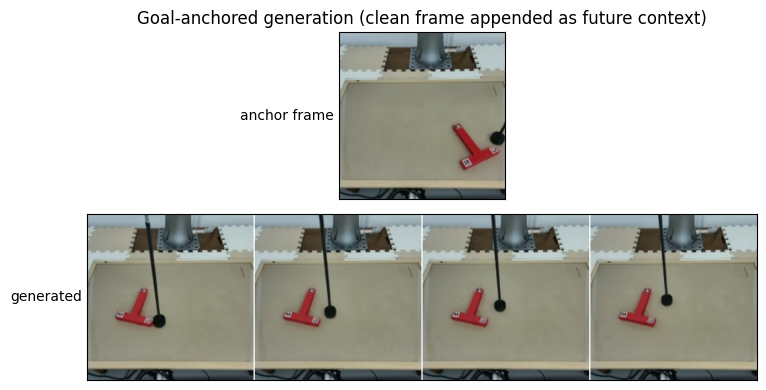

In [10]:
video_length, n_steps = 4, 32
N_lat, D_lat = cfg.denoiser.num_latent_tokens, cfg.denoiser.latent_dim

z_t = torch.randn(1, video_length, N_lat, D_lat, device=device)
context = latents[:, 10:11].clone()   # one clean frame used as a future anchor
dt = 1.0 / n_steps
for k in range(n_steps):
    tau = k / n_steps
    x, v = getVelField(denoiser, z_t, tau, context=context, context_tau=0.8, context_at_end=True)
    z_t = z_t + v * dt

plotComparison([
    ('anchor frame', decode(context)[0]),
    ('generated', decode(x)[0]),
], n_frames=8, title='Goal-anchored generation (clean frame appended as future context)')

In [11]:
###
video_length=4
n_steps = 32
dt = 1./float(n_steps)
z_t = torch.randn(1, video_length, 256, 32, device=device, dtype=torch.float32)
context = latents[:, 10, ...].clone().unsqueeze(1)  # (1, 1, 256, 32)


for k in range(n_steps):
    tau = k/n_steps
    x, v = getVelField(denoiser, z_t, tau, context=context, context_tau=0.8, context_at_end=True)
    z_t = z_t + v*dt


with torch.no_grad():
    img_vid = tokenizer.decode(x)
    context_vid = tokenizer.decode(context)

plotVideo(img_vid[0].to(torch.float32))
plotVideo(context_vid[0].to(torch.float32))

## 10. Classifier-free guidance — weight sweep

Blend the unconditional and context-conditioned velocities at several guidance
strengths `w`. The conditioning anchor is the first clean frame.

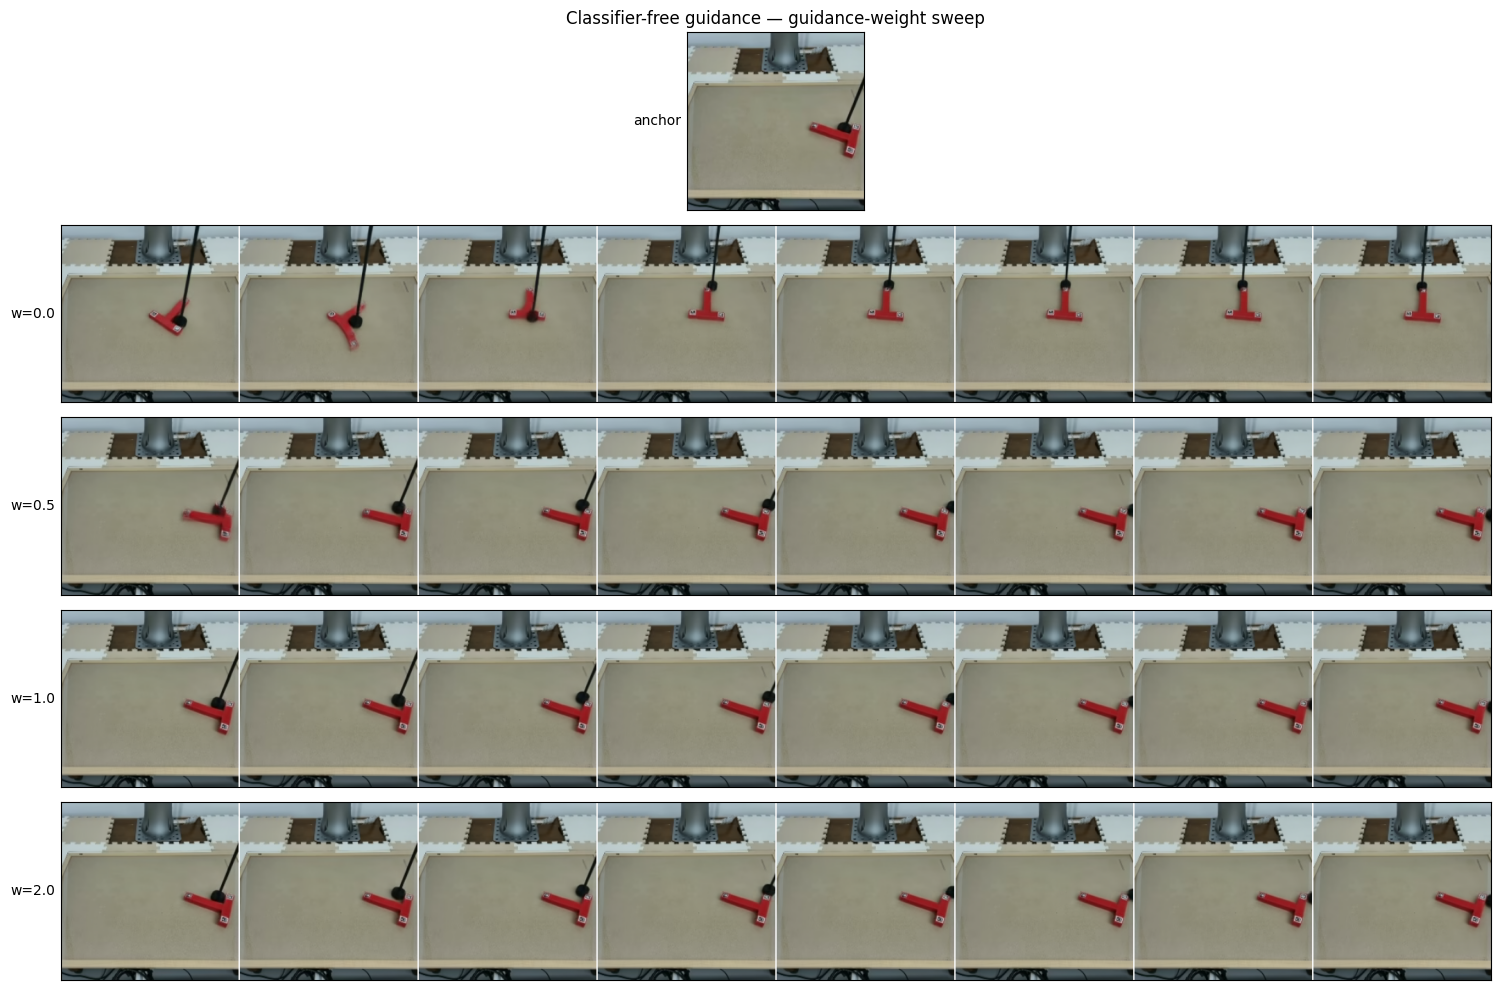

In [12]:
video_length, n_steps = 8, 8
N_lat, D_lat = cfg.denoiser.num_latent_tokens, cfg.denoiser.latent_dim
context = latents[:, 0:1].clone()     # first frame as the conditioning anchor


@torch.no_grad()
def cfg_sample(denoiser, context, w, video_length=8, n_steps=8, seed=0):
    """Classifier-free-guided generation at guidance strength ``w``.

    Each step blends v = v_uncond + w * (v_cond - v_uncond). Returns the
    integrated (guided) latents (1, video_length, N_lat, D_lat).
    """
    torch.manual_seed(seed)  # same prior across w for a fair comparison
    d = denoiser.cfg.denoiser
    device = context.device
    z_t = torch.randn(1, video_length, d.num_latent_tokens, d.latent_dim, device=device)
    dt = 1.0 / n_steps
    for k in range(n_steps):
        tau = k / n_steps
        _, v_un = getVelField(denoiser, z_t, tau)                                  # unconditional
        _, v_co = getVelField(denoiser, z_t, tau, context=context, context_tau=1.0)  # conditioned
        v = v_un + w * (v_co - v_un)
        z_t = z_t + v * dt
    return z_t


rows = [('anchor', decode(context)[0])]
for w in [0.0, 0.5, 1.0, 2.0]:
    z_w = cfg_sample(denoiser, context, w, video_length, n_steps)
    rows.append((f'w={w}', decode(z_w)[0]))
plotComparison(rows, n_frames=8, title='Classifier-free guidance — guidance-weight sweep')

In [13]:
###
video_length=8
n_steps = 8

w = 0.7
dt = 1./float(n_steps)
z_t = torch.randn(1, video_length, 256, 32, device=device, dtype=torch.float32)
context = latents[:, 0, ...].clone().unsqueeze(1)  # (1, 1, 256, 32)

for k in range(n_steps):
    tau = k/n_steps
    x_uncon, v_uncon = getVelField(denoiser, z_t, tau)
    x_con, v_con = getVelField(denoiser, z_t, tau, context=context, context_tau=1.0, context_at_end=False)
    
    v = v_uncon + w*(v_con-v_uncon)
    z_t[:] = z_t + v*dt


with torch.no_grad():
    img_vid = tokenizer.decode(x_uncon)
    img_vid_con = tokenizer.decode(context)

plotVideo(img_vid_con[0].to(torch.float32))
plotVideo(img_vid[0].to(torch.float32))


# Part II — Horizon sampling: batch-mode vs autoregressive

Condition on the clean context frames from the split above (§6) and generate the
future horizon two ways, scoring each against the ground-truth continuation:

1. **Batch mode** — denoise the entire horizon in parallel (one forward pass per
   flow-matching step). Cheap; drifts as the horizon grows.
2. **Autoregressive** — KV-cached frame-by-frame rollout via `HybridChunkSampler`.
   `chunk_size=1` is in-distribution for this checkpoint; `chunk_size>1` uses
   bidirectional-within-chunk attention the model never saw at training time (OOD).

## 11. Samplers

Two factored, self-contained samplers. `batch_sample` denoises the whole horizon
at once; `ar_rollout` wraps `HybridChunkSampler` for KV-cached rollout. Both read
their dims from the denoiser config, so they take only tensors as input.

In [14]:
@torch.no_grad()
def batch_sample(denoiser, ctx_z, ctx_a, T_hor, K=32, B=1, ctx_tau=1.0):
    """Generate a full horizon in parallel via flow matching, context-conditioned.

    Every Euler step is a single forward pass over ``[context | horizon]``: the
    context frames are pinned clean so the horizon attends to them, while the
    horizon frames integrate from pure noise (tau=0) to clean (tau=1).

    Args:
        denoiser: DenoiserWrapper (carries cfg + dims).
        ctx_z: clean context latents (1, T_ctx, N_lat, D_lat).
        ctx_a: clean context actions (1, T_ctx, n_act).
        T_hor: horizon length to generate.
        K: number of flow-matching Euler steps.
        B: number of independent samples (different noise) from the same context.
        ctx_tau: cleanness assigned to the context frames (~1 = clean).

    Returns:
        (z, a): horizon latents (B, T_hor, N_lat, D_lat) and actions (B, T_hor, n_act).
    """
    d = denoiser.cfg.denoiser
    N, N_lat, D_lat, n_act = d.num_noise_levels, d.num_latent_tokens, d.latent_dim, d.n_actions
    device = ctx_z.device
    Tc = ctx_z.shape[1]
    ctx_z = ctx_z.expand(B, -1, -1, -1).contiguous()
    ctx_a = ctx_a.expand(B, -1, -1).contiguous()
    z = torch.randn(B, T_hor, N_lat, D_lat, device=device)   # horizon prior (tau=0)
    a = torch.randn(B, T_hor, n_act, device=device)
    T = Tc + T_hor
    step_idx = torch.zeros((B, T), dtype=torch.long, device=device)   # shortcut step (flow mode -> 0)
    is_hor = make_is_horizon(T, ctx_len=Tc, device=device)            # ignored when horizon_aware=false
    ctx_idx = _quantize_tau_to_idx(ctx_tau, N)
    cur, dt = 0.0, 1.0 / K
    for _ in range(K):
        z_in = torch.cat([ctx_z, z], dim=1)                           # re-attach clean context
        a_in = torch.cat([ctx_a, a], dim=1)
        sig = torch.full((B, T), _quantize_tau_to_idx(cur, N), dtype=torch.long, device=device)
        sig[:, :Tc] = ctx_idx                                         # keep context clean
        z_hat, a_hat, _ = denoiser(
            noisy_act=a_in, noisy_obs=z_in,
            obs_sigma_idx=sig, obs_step_idx=step_idx,
            act_sigma_idx=sig, act_step_idx=step_idx, is_horizon=is_hor,
        )
        zh, ah = z_hat[:, Tc:], a_hat[:, Tc:].squeeze(-2)             # horizon slice only
        denom = max(1.0 - cur, 1e-5)                                  # v = (x_hat - x) / (1 - tau)
        z = z + (zh - z) / denom * dt
        a = a + (ah - a) / denom * dt
        cur += dt
    return z, a


@torch.no_grad()
def ar_rollout(denoiser, cfg, ctx_z, ctx_a, n_frames, chunk_size=1, commit=1, K=8):
    """KV-cached autoregressive rollout via HybridChunkSampler.

    Warms the cache on the context frames, then emits ``n_frames`` of horizon
    ``commit`` frames at a time.

    Args:
        denoiser, cfg: model wrapper and full Hydra config.
        ctx_z, ctx_a: clean context latents/actions to warm the cache with.
        n_frames: total horizon frames to generate.
        chunk_size: frames denoised per chunk (m). 1 = pure causal decode
            (in-distribution here); >1 = bidirectional-within-chunk (OOD for a
            horizon_aware=false checkpoint).
        commit: frames committed to cache per chunk (k <= chunk_size).
        K: denoising steps per chunk.

    Returns:
        (z, a): latents (1, n_frames, N_lat, D_lat) and actions (1, n_frames, n_act).
    """
    s = HybridChunkSampler(
        denoiser, cfg, chunk_size=chunk_size, commit_per_chunk=commit,
        num_diffusion_steps=K, device='cuda', dtype=torch.float32,
    )
    s.suppress_horizon_warning = True
    s.init_cache(batch_size=ctx_z.shape[0])
    s.warm_up_cache(ctx_z, ctx_a)              # commit clean context into the KV cache
    return s.generate(n_frames)

## 12. Batch mode — horizon-length sweep

Generate horizons of growing length from the same context and watch the
latent MSE grow as the parallel denoise has to commit a longer trajectory.

[batch] horizon= 8  latent_mse_vs_GT=0.0043
[batch] horizon=16  latent_mse_vs_GT=0.0042
[batch] horizon=32  latent_mse_vs_GT=0.0050


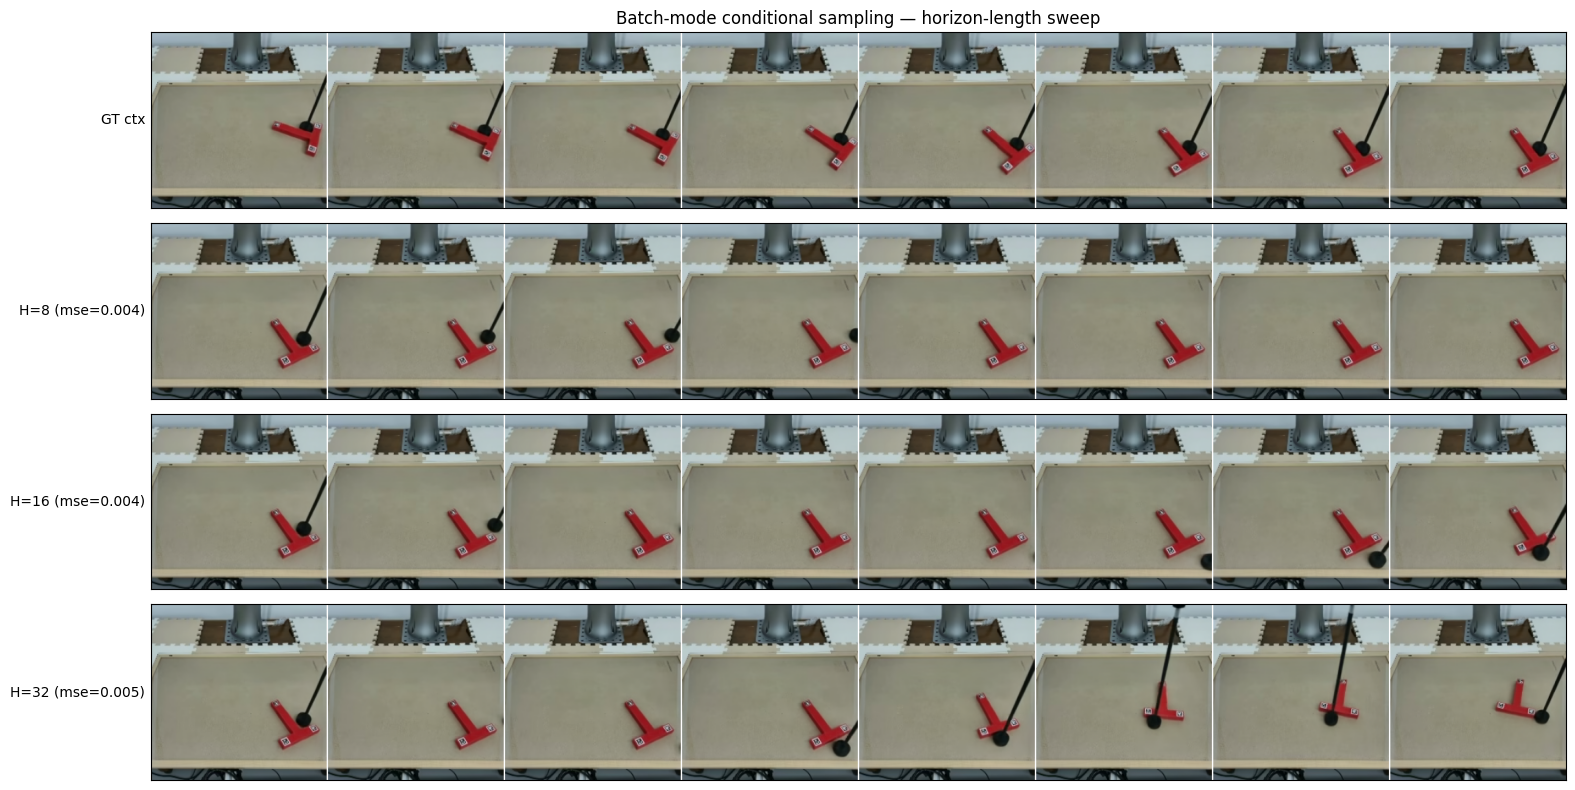

In [15]:
batch_videos = [('GT ctx', decode(ctx_latents)[0])]
for Th in [8, 16, 32]:
    z, _ = batch_sample(denoiser, ctx_latents, ctx_actions, Th, K=32, B=1)
    m = latent_mse(z, latents[:, T_ctx:T_ctx + Th])
    print(f'[batch] horizon={Th:2d}  latent_mse_vs_GT={m:.4f}')
    batch_videos.append((f'H={Th} (mse={m:.3f})', decode(z)[0]))

plotComparison(batch_videos, n_frames=8, title='Batch-mode conditional sampling — horizon-length sweep')

## 13. Batch mode — sample diversity

Same context, four different noise priors. Plausible but distinct pusher
trajectories indicate genuine diversity (no mode collapse).

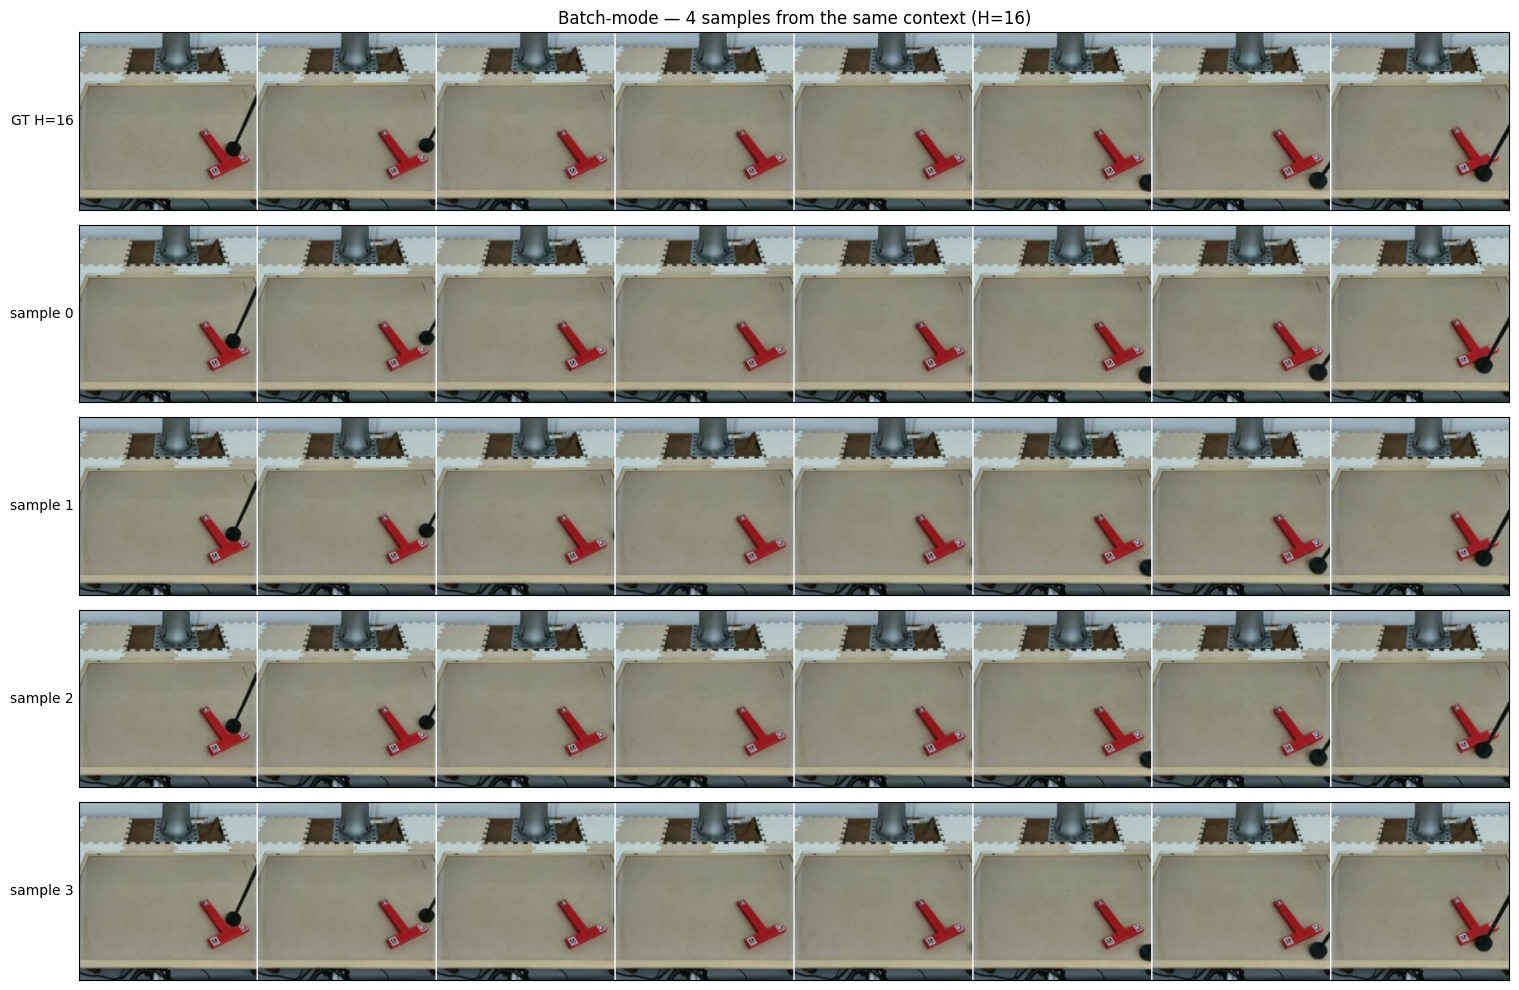

In [16]:
z, _ = batch_sample(denoiser, ctx_latents, ctx_actions, 16, K=32, B=4)
vids = decode(z)
diversity = [('GT H=16', decode(latents[:, T_ctx:T_ctx + 16])[0])]
diversity += [(f'sample {i}', vids[i]) for i in range(4)]
plotComparison(diversity, n_frames=8, title='Batch-mode — 4 samples from the same context (H=16)')

## 14. Autoregressive rollout

In-distribution single-frame decode (`m=1`) vs the OOD chunked variant (`m=4`),
both KV-cached and warmed on the same context.

/tmp/ipykernel_1846070/3743975980.py:72: RuntimeWarning: [HybridChunkSampler] cfg.denoiser.horizon_aware=False — the model was trained with purely-causal temporal attention. This sampler uses bidirectional attention within the active chunk, which the model has NOT been trained on. Predictions are out-of-distribution and quality may degrade significantly. To use this sampler as intended, train (or fine-tune) with horizon_aware=True. Override with cfg.denoiser.horizon_aware=True or set self.suppress_horizon_warning=True to silence.
  s = HybridChunkSampler(


[HybridChunkSampler] cfg.denoiser.horizon_aware=False — the model was trained with purely-causal temporal attention. This sampler uses bidirectional attention within the active chunk, which the model has NOT been trained on. Predictions are out-of-distribution and quality may degrade significantly. To use this sampler as intended, train (or fine-tune) with horizon_aware=True. Override with cfg.denoiser.horizon_aware=True or set self.suppress_horizon_warning=True to silence.
[HybridChunkSampler] cfg.denoiser.horizon_aware=False — the model was trained with purely-causal temporal attention. This sampler uses bidirectional attention within the active chunk, which the model has NOT been trained on. Predictions are out-of-distribution and quality may degrade significantly. To use this sampler as intended, train (or fine-tune) with horizon_aware=True. Override with cfg.denoiser.horizon_aware=True or set self.suppress_horizon_warning=True to silence.
[AR] m=1 (in-dist)  mse=0.0036
[AR] m=4 (O

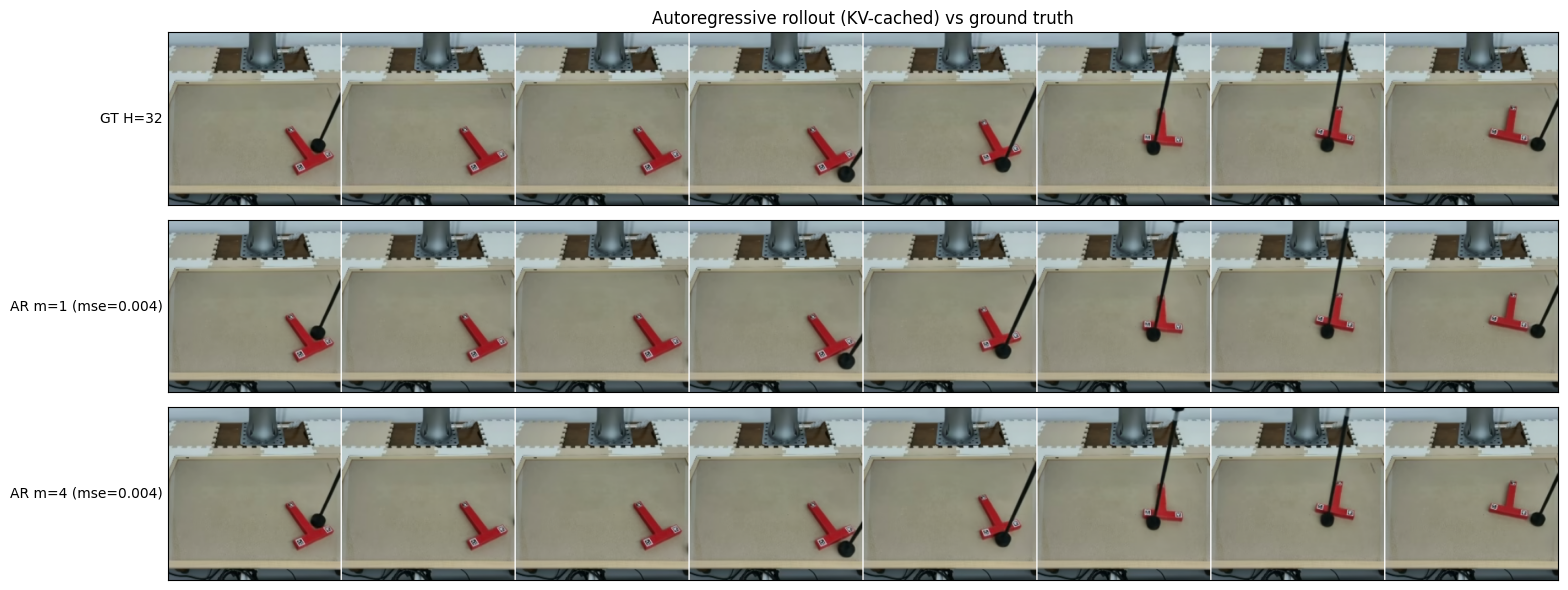

In [17]:
z_ar1, _ = ar_rollout(denoiser, cfg, ctx_latents, ctx_actions, T_hor, chunk_size=1, commit=1, K=8)
z_ar4, _ = ar_rollout(denoiser, cfg, ctx_latents, ctx_actions, T_hor, chunk_size=4, commit=4, K=16)

m1 = latent_mse(z_ar1[:, :T_hor], gt_horizon)
m4 = latent_mse(z_ar4[:, :T_hor], gt_horizon)
print(f'[AR] m=1 (in-dist)  mse={m1:.4f}')
print(f'[AR] m=4 (OOD)      mse={m4:.4f}')

plotComparison([
    ('GT H=32', decode(gt_horizon)[0]),
    (f'AR m=1 (mse={m1:.3f})', decode(z_ar1[:, :T_hor])[0]),
    (f'AR m=4 (mse={m4:.3f})', decode(z_ar4[:, :T_hor])[0]),
], n_frames=8, title='Autoregressive rollout (KV-cached) vs ground truth')

## 15. Play a rollout

In [18]:
# Inline video of the in-distribution autoregressive rollout.
plotVideo(decode(z_ar1[:, :T_hor])[0], fps=8)

This browser does not support the video tag.
